This is an image classification problem (4 classes of surface defects).


Class 'dent': 120 images
Class 'normal': 120 images
Class 'scratch': 120 images
Class 'stain': 120 images
dent image size: (96, 96)
normal image size: (96, 96)
scratch image size: (96, 96)
stain image size: (96, 96)


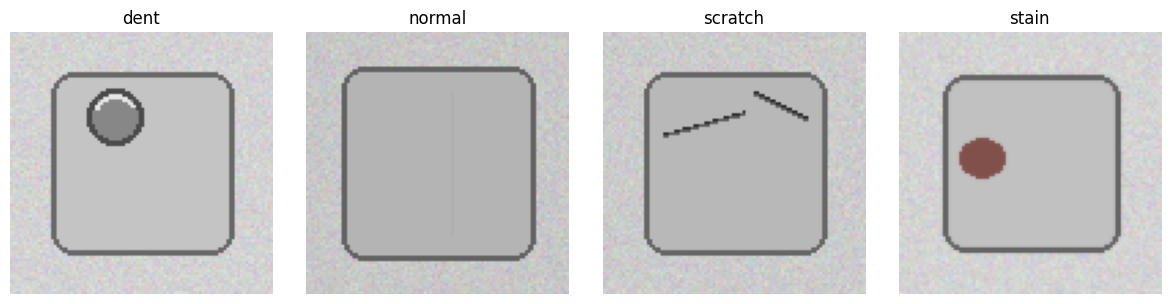

In [8]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

data_dir = '../Source Datasets/part_2_cnn_computer_vision/images'
classes = os.listdir(data_dir)
classes = [c for c in classes if not c.startswith('.')]  # remove hidden files

for cls in classes:
    count = len(os.listdir(os.path.join(data_dir, cls)))
    print(f"Class '{cls}': {count} images")

# Show sample image from each class
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, cls in enumerate(sorted(classes)):
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')
    print(f"{cls} image size: {img.size}")
plt.tight_layout()
plt.savefig('./results/accuracy_loss_curves.png')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split

IMG_SIZE = 64
images, labels = [], []
label_map = {cls: i for i, cls in enumerate(sorted(classes))}

for cls in sorted(classes):
    folder = os.path.join(data_dir, cls)
    for fname in os.listdir(folder):
        if fname.endswith('.png'):
            img = Image.open(os.path.join(folder, fname)).resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img) / 255.0)
            labels.append(label_map[cls])

X = np.array(images)
y = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (384, 64, 64, 3) | Test shape: (96, 64, 64, 3)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

C:\Users\ramya\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         802,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 822,532 (3.14 MB)

 Trainable params: 822,532 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 6.8719e-04 - val_accuracy: 1.0000 - val_loss: 0.0295
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 6.5525e-04 - val_accuracy: 1.0000 - val_loss: 0.0312
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 1.0000 - loss: 6.0689e-04 - val_accuracy: 0.9744 - val_loss: 0.0371
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 1.0000 - loss: 5.8667e-04 - val_accuracy: 1.0000 - val_loss: 0.0242
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 1.0000 - loss: 5.8491e-04 - val_accuracy: 0.9744 - val_loss: 0.0404
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 1.0000 - loss: 5.4622e-04 - val_accuracy: 1.0000 - val_loss: 0.0312
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 1.0000 - loss: 5.0257e-04 - val_accuracy: 1.0000 - val_loss: 0.0295
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 1.0000 - loss: 4.930

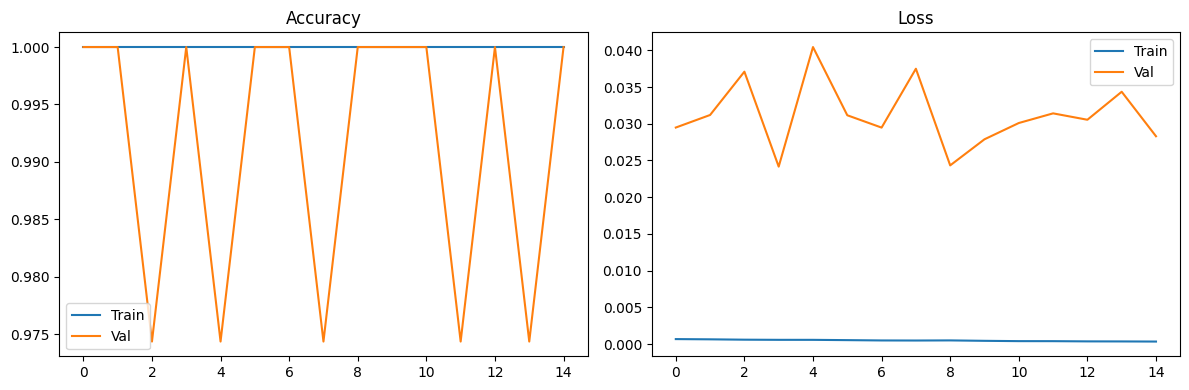

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


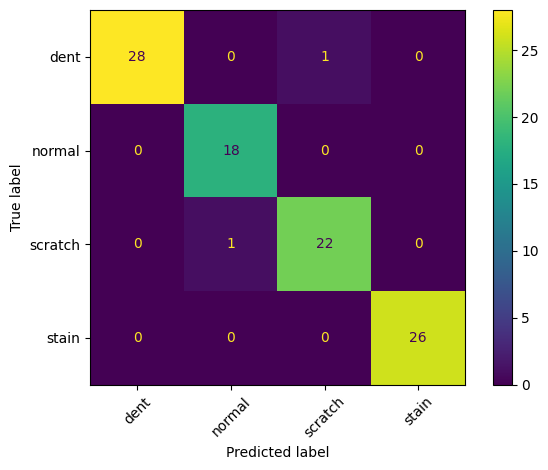

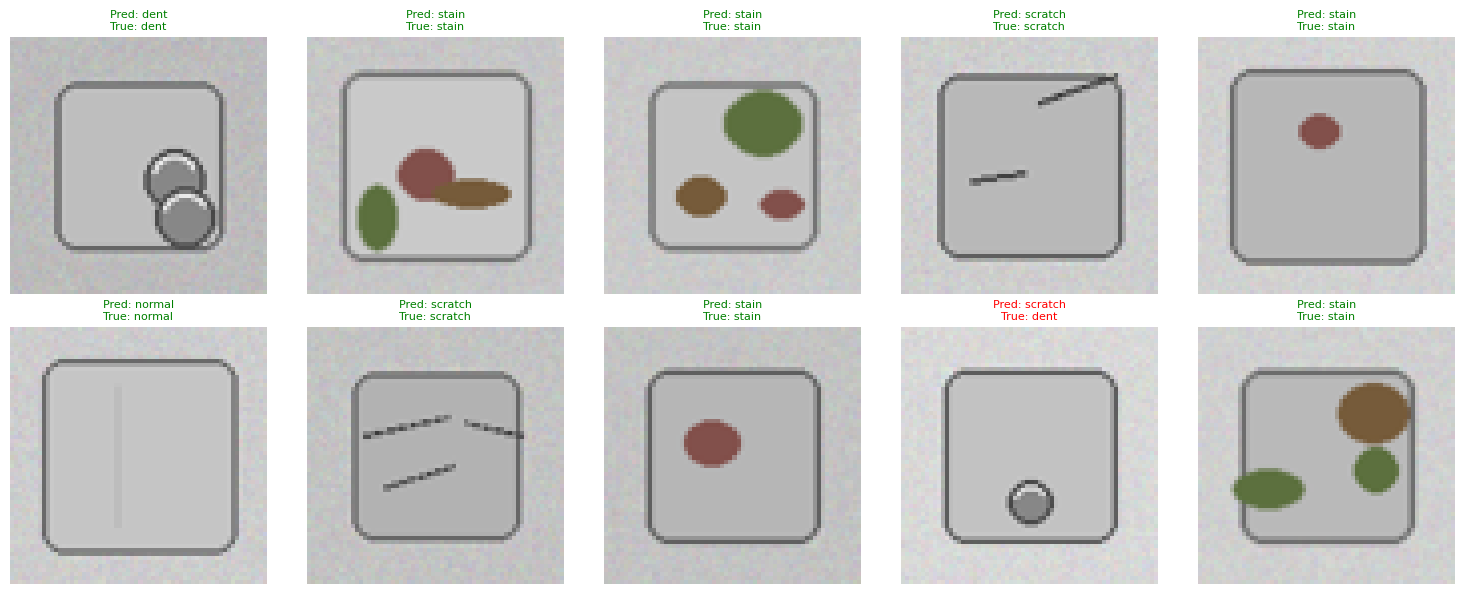

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

history = cnn_model.fit(X_train, y_train, epochs=15, batch_size=16, validation_split=0.1, verbose=1)

test_loss, test_acc = cnn_model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot accuracy/loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train'); ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'], label='Train'); ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout()
plt.savefig('./results/accuracy_loss_curves.png')
plt.show()

# Confusion matrix
y_pred = np.argmax(cnn_model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(classes))
disp.plot(xticks_rotation=45)
plt.tight_layout()
plt.savefig('./results/confusion_matrix.png')
plt.show()

# Sample predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
class_names = sorted(classes)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i])
    pred = class_names[y_pred[i]]
    true = class_names[y_test[i]]
    ax.set_title(f"Pred: {pred}\nTrue: {true}", color='green' if pred==true else 'red', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('./sample_predictions/prediction_outputs.png')
plt.show()

## Task 6: CNN Concept Explanation

### What is convolution?
Convolution is the core operation in a CNN. A small filter (like a 3x3 grid)
slides across the image and at each position multiplies its values with the
pixel values underneath, then sums them up. This produces a "feature map"
that highlights where certain patterns — like edges, curves, or textures —
appear in the image. Instead of looking at the whole image at once, the
network learns to detect small local patterns first, then builds up to more
complex shapes in deeper layers.

### Why is pooling used?
Pooling (we used MaxPooling) reduces the size of the feature maps by keeping
only the strongest signal from each small region. This achieves two things:
it reduces the amount of computation needed, and it makes the model less
sensitive to the exact position of a feature — a dent detected slightly
left or right will still be recognised. This is called spatial invariance
and is very useful for real-world images where objects are rarely in the
exact same position every time.

### Why is ReLU commonly used in CNNs?
ReLU (Rectified Linear Unit) sets any negative value to zero and keeps
positive values as-is. It is used because it is computationally simple,
trains faster than older activation functions like sigmoid or tanh, and
does not suffer from the "vanishing gradient" problem where gradients
become too small for deep networks to learn effectively. It also introduces
the non-linearity that allows CNNs to learn complex visual patterns.

### Why are CNNs better than regular feed-forward networks for image data?
A regular feed-forward network treats every pixel as an independent input,
which ignores the spatial relationship between neighbouring pixels. It also
requires an enormous number of parameters for even a small image. CNNs
solve both problems: they use shared filters that scan across the image
(far fewer parameters), and they are specifically designed to detect local
spatial patterns like edges and textures. This makes them much more
efficient and accurate for image tasks.

## Task 7: Business Use Case Mapping — Manufacturing Quality Inspection

### Domain: Manufacturing

### The Problem
In a manufacturing plant, products coming off an assembly line must be
inspected for surface defects before they are shipped. Traditionally this
is done by human visual inspectors, which is slow, expensive, inconsistent,
and prone to fatigue-related errors — especially at high production speeds.

### The AI Solution
A CNN-based image classification system — exactly like the model we built —
can be installed at the end of the production line with a camera. Every
product is photographed and the model instantly classifies it as:
- **Normal** → pass, proceed to packaging
- **Dent / Scratch / Stain** → flag for rejection or rework

Our model achieved 97.92% accuracy on this exact type of classification,
correctly identifying 94 out of 96 test images.

### Business Impact
- Inspection speed increases from seconds per item (human) to milliseconds (AI)
- Consistent quality standards applied 24/7 without fatigue
- Reduces cost of defective products reaching customers
- Frees human inspectors for higher-value tasks like root cause analysis

### Model Behaviour Observation
The accuracy and loss curves show that our training accuracy reached 100%
while validation accuracy fluctuated — a sign of mild overfitting. In a
production setting, this would be addressed by collecting more diverse
training images, applying data augmentation, and using dropout layers.
The two errors (1 dent misclassified as scratch, 1 scratch as normal)
are understandable since these defects can visually overlap at small
image sizes.